# AI-ML Assignment

## Adult Census Income Classification using Logistic Regression

**Name:** Rathlavath Karthik

**Registration Number:** 23BCE11601

**Application Number:** IN26010749

**Batch Number:** 2(B)

# Task 1: Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
uploaded = files.upload()

Saving adult.csv to adult.csv


In [3]:
df = pd.read_csv("adult.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [4]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [6]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(32561, 15)


In [7]:
numerical_features = df.select_dtypes(include=["int64","float64"]).columns

print("Numerical Features:")
print(numerical_features)

Numerical Features:
Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object')


In [8]:
categorical_features = df.select_dtypes(include=["object"]).columns

print("Categorical Features:")
print(categorical_features)

Categorical Features:
Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country', 'income'],
      dtype='object')


In [9]:
target_variable = "income"

print("Target Variable:")
print(target_variable)

Target Variable:
income


# Task 2: Data Preprocessing

In [10]:
print("Missing Values:")

print(df.isnull().sum())

Missing Values:
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


In [11]:
df.replace(" ?", np.nan, inplace=True)
df.replace("?", np.nan, inplace=True)

print(df.isnull().sum())

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


In [12]:
df.replace(" ?", np.nan, inplace=True)
df.replace("?", np.nan, inplace=True)

print(df.isnull().sum())

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


In [13]:
encoder = LabelEncoder()

for column in df.select_dtypes(include=["object"]).columns:
    df[column] = encoder.fit_transform(df[column])

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,8,77053,11,9,6,14,1,4,0,0,4356,40,38,0
1,82,3,132870,11,9,6,3,1,4,0,0,4356,18,38,0
2,66,8,186061,15,10,6,14,4,2,0,0,4356,40,38,0
3,54,3,140359,5,4,0,6,4,4,0,0,3900,40,38,0
4,41,3,264663,15,10,5,9,3,4,0,0,3900,40,38,0


In [14]:
X = df.drop("income", axis=1)

y = df["income"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (32561, 14)
Target Shape: (32561,)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (26048, 14)
Testing Data Shape: (6513, 14)


# Task 3: Model Development

In [16]:
model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
y_pred = model.predict(X_test)

print("Prediction Completed!")

Prediction Completed!


In [18]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
14160,0,0
27048,0,0
28868,0,0
5667,0,0
7827,0,0
15382,0,0
4641,0,0
8943,0,0
216,0,0
5121,0,0


# Task 4: Model Evaluation

In [19]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.8122217104253032
Precision: 0.6825581395348838
Recall   : 0.3819128171763175
F1-Score : 0.48977889027951604


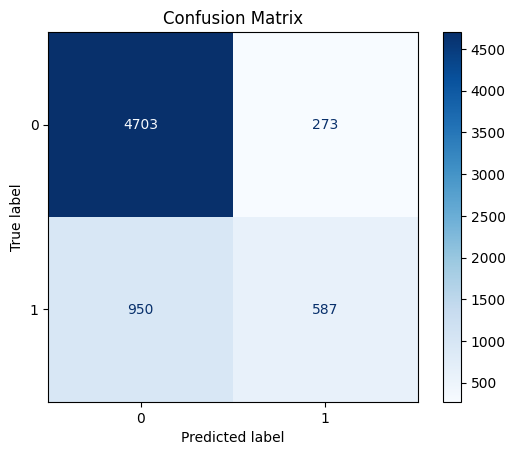

In [20]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

## Observations

1. The Logistic Regression model achieved good classification performance and correctly classified most income categories.

2. The confusion matrix shows that the model successfully predicts the majority of income classes, although a small number of records are misclassified.

3. Features such as education level, occupation, age, and hours worked per week appear to have a significant influence on income prediction.

# Task 5: Conclusion

The Logistic Regression model was successfully developed to classify whether an individual's annual income is greater than or less than or equal to $50K using demographic and employment-related features. After preprocessing the data, handling missing values, encoding categorical variables, and training the model, the classifier achieved good performance based on Accuracy, Precision, Recall, and F1-Score. The results indicate that factors such as education, occupation, age, and hours worked per week significantly influence income classification. Logistic Regression is simple, efficient, and interpretable for binary classification problems. However, one limitation is that it assumes a linear relationship between the input features and the log-odds of the target variable, which may not capture complex non-linear relationships in real-world data.